In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [3]:
import tensorflow as tf
import model.embedding as embedding
import model.utils as utils
import model.attention as attn
import model.encoder as encoder
import model.decoder as decoder
import model.model as myM
import model.informer as Informer
from model.data import getMyData

In [4]:
#TEST My Forecast
DATA_SIZE = 3000 #TTFData.shape[0]
SEQ_LEN = 100
BATCH_SIZE = 32

<HR></HR>
<H1>DATA Génération</H1>

In [5]:
myDataFct = getMyData(data_size=DATA_SIZE, seq_len=SEQ_LEN,batch_len=BATCH_SIZE)
dataset, datasetVal = myDataFct.get()

2024-09-03 19:03:51.937871: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-09-03 19:03:51.937888: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-09-03 19:03:51.937892: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-09-03 19:03:51.937921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-09-03 19:03:51.937934: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


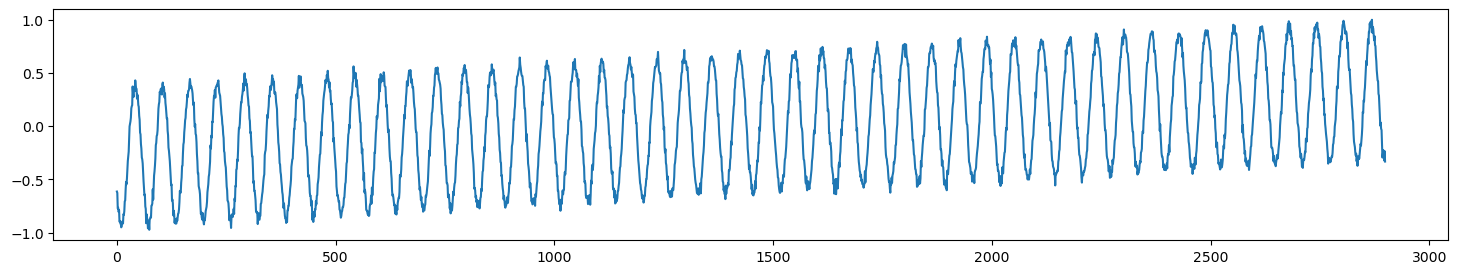

In [6]:
myDataFct.display()

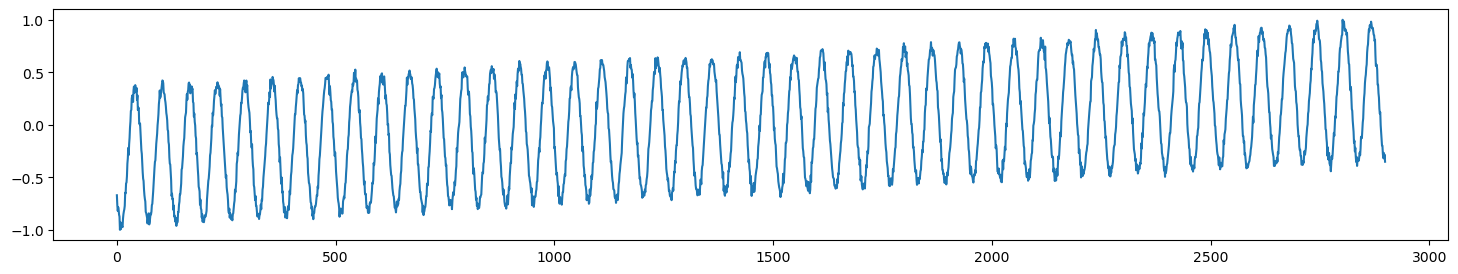

In [7]:
# Sinusoide de TEST
x = np.sin(np.linspace(0, 0.1*DATA_SIZE, DATA_SIZE))
x_random = np.random.normal(0, 0.05, DATA_SIZE) # add noise
x_rampe = np.linspace(0,0.1*DATA_SIZE,DATA_SIZE)/DATA_SIZE*10 # add rampe
# x = x+x_random
x = x+x_random + x_rampe
x,scaler = utils.Normalize(x)
# x,scaler,xOrg = conver2diff(x, DATA_SIZE, False)
# x = Norm(x)
# Create a dataset
X = np.array([x[ii:ii+SEQ_LEN] for ii in range(0, x.shape[0]-SEQ_LEN)], dtype=np.float32)
Y = np.array([x[ii+SEQ_LEN] for ii in range(0, x.shape[0]-SEQ_LEN)], dtype=np.float32)
X = X.astype('float32')
Y = Y.astype('float32')

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=369, shuffle=True)#, stratify=Y)

dataset = tf.data.Dataset.from_tensor_slices((X_train,y_train))
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.shuffle(BATCH_SIZE)
datasetVal = tf.data.Dataset.from_tensor_slices((X_val,y_val))
datasetVal = datasetVal.batch(BATCH_SIZE)
datasetVal = datasetVal.shuffle(BATCH_SIZE)

fig = plt.figure(figsize=(18,3))
plt.plot(Y);

In [8]:
####
#TEST My Forecast
h = 8
d_model = 64
d_ff = 512
RATE = 0.1
N = 6
EPOCHS = 12
LR = 2.5e-6

In [9]:
btX = (list(enumerate(dataset))[0][1][0])
btY = (list(enumerate(dataset))[0][1][1])
# btX = tf.reshape(btX, shape=[btX.shape[0],SEQ_LEN,1])
# for i,(btX,btY) in enumerate(dataset):
#     # print(btX)
#     btY = tf.reshape(btY,shape=[btY.shape[0],1])
#     btX = tf.reshape(btX, shape=[btX.shape[0],SEQ_LEN,1])
#    step(btX,btY)


2024-09-03 19:03:52.207870: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [2320,1]
	 [[{{node Placeholder/_1}}]]
2024-09-03 19:03:52.208027: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [2320,1]
	 [[{{node Placeholder/_1}}]]


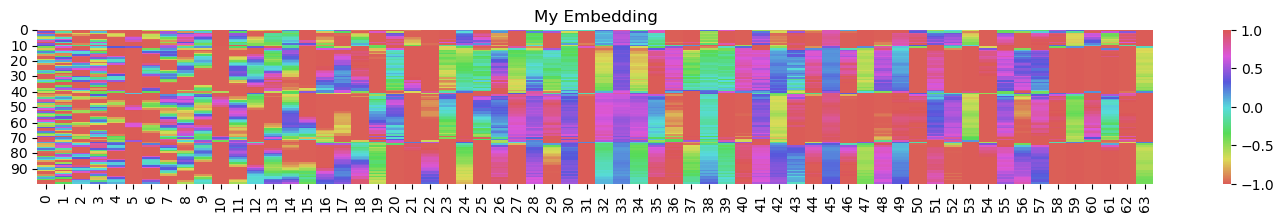

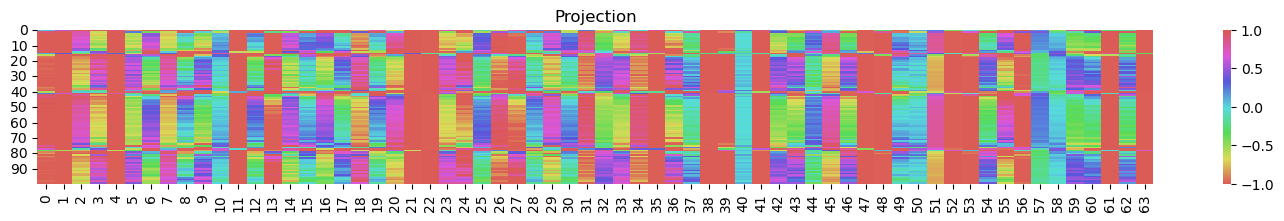

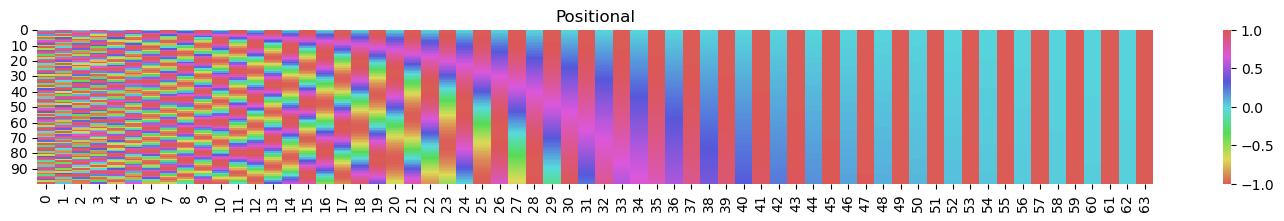

In [10]:
# test convEmbedding
myE = embedding.myEmbedding(SEQ_LEN,d_model,RATE)
myProj = embedding.projEmbedding(d_model,RATE)
myPos = embedding.PositionEmbedding(SEQ_LEN,d_model)
myPJX = myProj(btX)
myEX = myE(btX)
myPX = myPos(btX)
sns.color_palette("hls", 8)
sns.color_palette("mako", as_cmap=True)
fig = plt.figure(figsize=(18,2))
sns.heatmap(myEX[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('My Embedding');
fig = plt.figure(figsize=(18,2))
sns.heatmap(myPJX[1], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Projection');
fig = plt.figure(figsize=(18,2))
sns.heatmap(myPX, vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');

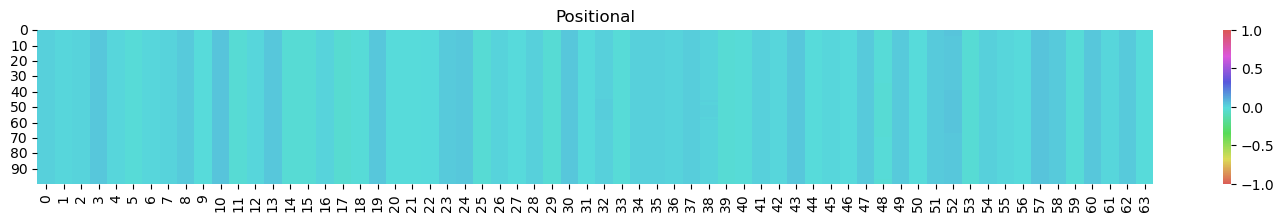

In [11]:
# test Attention

AttFct = attn.MultiHeadAttention(h=h, d_model=d_model)
Att,Weight = AttFct(btX)   # (32,8,64) et (32,8,8,8) (batch, head, d_model)
fig = plt.figure(figsize=(18,2))
sns.heatmap(Att[3], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');

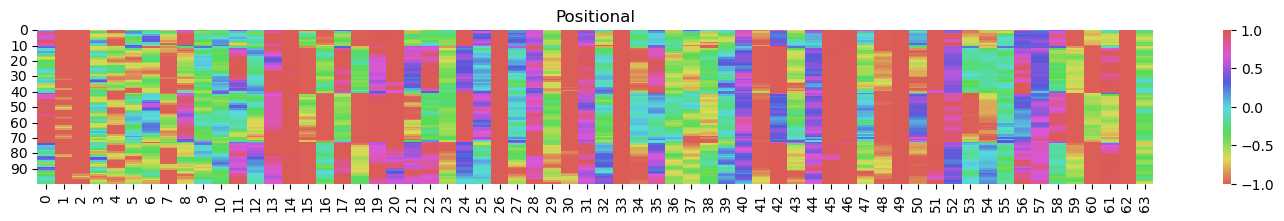

In [12]:
# test encoder
EncFct = encoder.Encoder(h=h, d_model=d_model,rate=RATE,d_ff=d_ff,N=N)
encOut = EncFct(myEX)
# print(encOut)
fig = plt.figure(figsize=(18,2))
sns.heatmap(encOut[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');

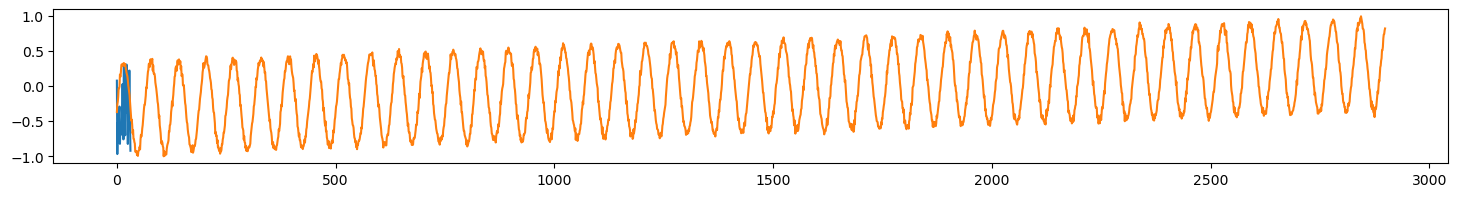

In [13]:
# test myForecast //use only encoder ///
# DecFct = decoder.Decoder(h=h,d_model=d_model,rate=RATE,d_ff=d_ff,N=N)
# decOut = DecFct(btX,btY)
# fig = plt.figure(figsize=(18,2))
# sns.heatmap(decOut[0], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Positional');

MyForecastFct = myM.myForcast(seq_len=SEQ_LEN,h=h,d_model=d_model,rate=RATE,d_ff=d_ff,N=N)
output = MyForecastFct(btX)
fig = plt.figure(figsize=(18,2))
plt.plot(output);
plt.plot(X[:,0,:]);

In [14]:
#TEST My Forecast
h = 8
d_model = 128
d_ff = 512
RATE = 0.1
N = 4
EPOCHS = 8
LR = 2.5e-6

MyForecastFct = myM.myForcast(seq_len=SEQ_LEN,h=h,d_model=d_model,rate=RATE,d_ff=d_ff,N=N)

informerFct = Informer.Informer(SEQ_LEN,MyForecastFct)
informerFct._build_model(LR=LR)
model = informerFct.train(dataset=dataset, datasetVal=datasetVal,epochs=EPOCHS)

2024-09-03 19:04:10.476049: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [580,100,1]
	 [[{{node Placeholder/_0}}]]
2024-09-03 19:04:10.476191: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [580,1]
	 [[{{node Placeholder/_1}}]]


Epoch: 0 -> loss=0.42/0.04 -> Accuracy=99.51%/99.84% - [17.96s]
Epoch: 1 -> loss=0.07/0.04 -> Accuracy=99.65%/99.84% - [16.04s]
Epoch: 2 -> loss=0.03/0.04 -> Accuracy=99.72%/99.83% - [15.80s]
Epoch: 3 -> loss=0.02/0.04 -> Accuracy=99.77%/99.83% - [15.85s]
Epoch: 4 -> loss=0.01/0.05 -> Accuracy=99.80%/99.82% - [15.87s]
Epoch: 5 -> loss=0.01/0.05 -> Accuracy=99.82%/99.82% - [15.92s]
Epoch: 6 -> loss=0.01/0.05 -> Accuracy=99.84%/99.82% - [15.97s]
Epoch: 7 -> loss=0.00/0.05 -> Accuracy=99.85%/99.82% - [16.01s]
Epoch: 8 -> loss=0.00/0.05 -> Accuracy=99.86%/99.82% - [16.09s]
Epoch: 9 -> loss=0.00/0.05 -> Accuracy=99.87%/99.82% - [16.21s]
Total time taken: 161.8s


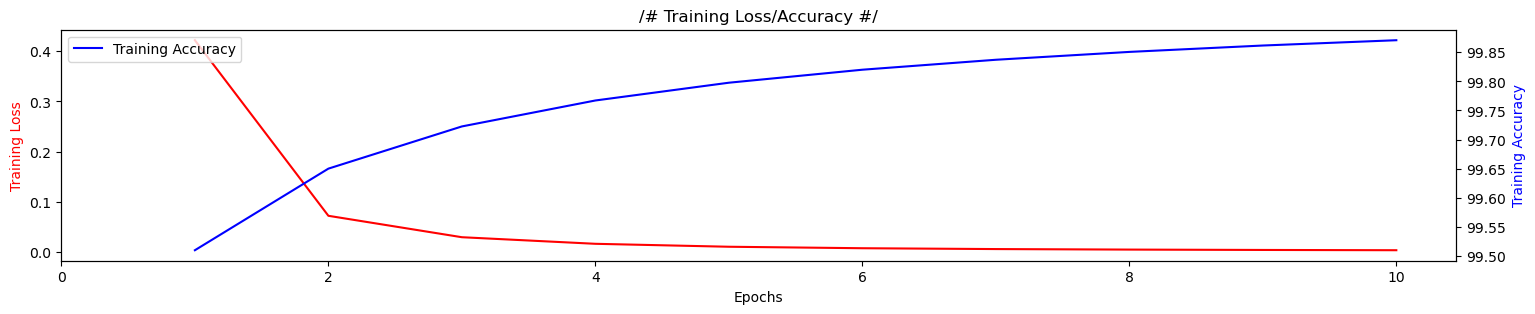

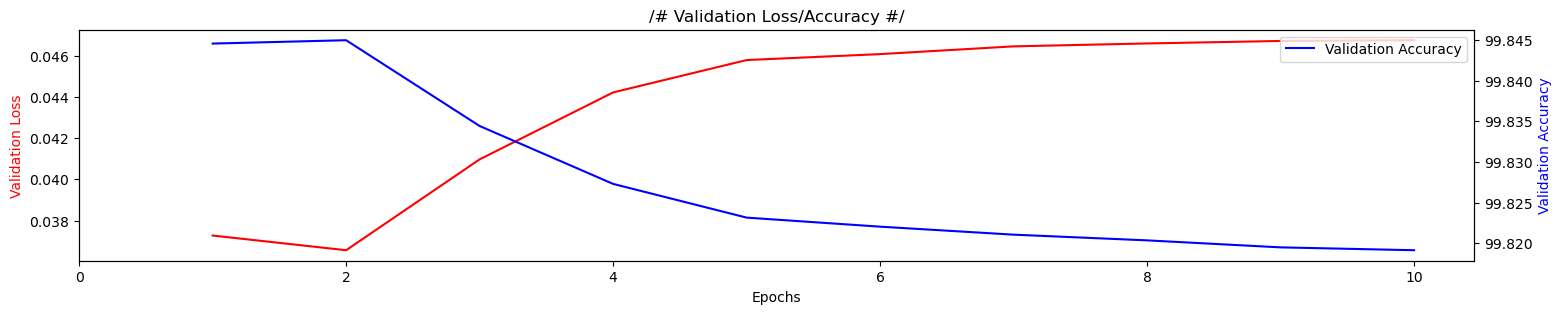

In [18]:
# Visualisation des Courbes d'appretissage
from numpy import arange
from pickle import load
 
# Load the training and validation loss dictionaries
train_loss = load(open('train_loss.pkl', 'rb'))
train_accuracy = load(open('train_accuracy.pkl', 'rb'))
val_loss = load(open('val_loss.pkl', 'rb'))
val_accuracy = load(open('val_accuracy.pkl', 'rb'))
 
# Retrieve each dictionary's values
train_values = train_loss.values()
train_acc_values = train_accuracy.values()
val_values = val_loss.values()
val_acc_values = val_accuracy.values()
 
# Generate a sequence of integers to represent the epoch numbers
g_epochs = range(1, EPOCHS+1)

fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, train_values, label='Training Loss', color='red')
# ax2.plot(g_epochs, train_values, label='Training Loss', color='blue')
ax2.plot(g_epochs, train_acc_values, label='Training Accuracy', color='blue')
 
# Add in a title and axes labels
plt.title('/# Training Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss',color='red')
ax2.set_ylabel('Training Accuracy',color='blue')
# Set the tick locations
plt.xticks(arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()
#----------------------------
fig, ax1 = plt.subplots(figsize=(18,3))
ax2 = ax1.twinx()
# Plot and label the training and validation loss values
ax1.plot(g_epochs, val_values, label='Validation Loss', color='red')
ax2.plot(g_epochs, val_acc_values, label='Validation Accuracy', color='blue')
# Add in a title and axes labels
plt.title('/# Validation Loss/Accuracy #/')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Validation Loss',color='red')
ax2.set_ylabel('Validation Accuracy',color='blue')
# Set the tick locations
plt.xticks(arange(0, EPOCHS+1, 2))
# Display the plot
plt.legend(loc='best');
# plt.show()

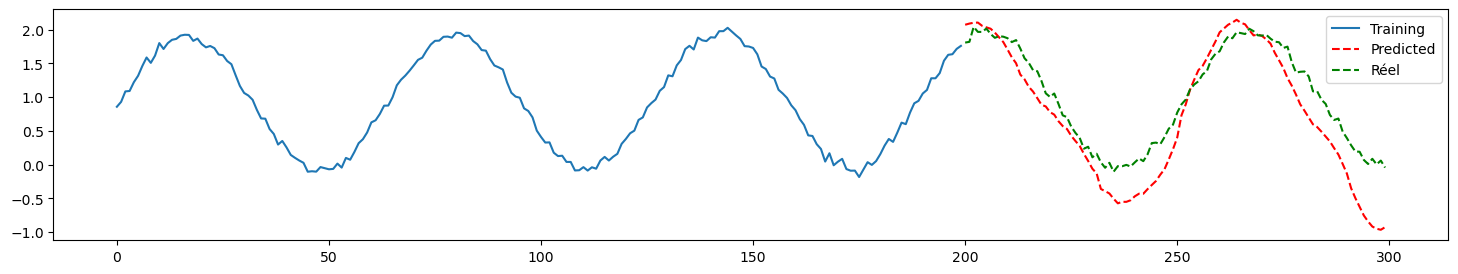

In [19]:
FORCAST = 100
LOOP= 3*FORCAST
x0 = x[:DATA_SIZE-FORCAST]
x1 = x[:DATA_SIZE]
x0 =tf.reshape(x0,shape=[DATA_SIZE-FORCAST])
x0 = tf.cast(x0, dtype=tf.float32)
for _ in range(FORCAST):
    xx = x0[len(x0)-SEQ_LEN:len(x0)]
    xx = tf.convert_to_tensor(xx, dtype=tf.float32)
    xx = tf.reshape(xx,shape=[1,SEQ_LEN,1])
    # myxE = MyE(xx, conv=True, training=False)
    yy = model(xx,training=False)
    yy = tf.reshape(yy,[1])
    x0 = np.concatenate((x0, yy))
# fig = plt.figure(figsize=(18,2))
# sns.heatmap(myxE[0], vmin=-1, vmax=1, cmap='Spectral');
# ADAPT from transformation initiale des data
x0 = scaler.inverse_transform(tf.reshape(x0,shape=[DATA_SIZE, 1]))
x1 = scaler.inverse_transform(tf.reshape(x1,shape=[DATA_SIZE, 1]))
# x0 = diff2org(tf.reshape(x0,shape=[DATA_SIZE, 1]),scaler,xOrg)
# x1 = diff2org(tf.reshape(x1,shape=[DATA_SIZE, 1]),scaler,xOrg)
# fig, ax = plt.subplots(figsize=(18,5))
# sns.lineplot(d[:], color='Blue');
fig = plt.figure(figsize=(18,3))
# plt.plot(range(x0[:DATA_SIZE-FORCAST].shape[0]),x0[:DATA_SIZE-FORCAST], label="Training");
# plt.plot(range(x0[:DATA_SIZE-FORCAST].shape[0], x0.shape[0]),x0[DATA_SIZE-FORCAST:DATA_SIZE], 'r--', label="Predicted");
# plt.plot(range(x1[:DATA_SIZE-FORCAST].shape[0], x1.shape[0]),x1[DATA_SIZE-FORCAST:DATA_SIZE], 'g--', label="Réel");
plt.plot(range(x0[DATA_SIZE-LOOP:DATA_SIZE-FORCAST].shape[0]),x0[DATA_SIZE-LOOP:DATA_SIZE-FORCAST], label="Training");
plt.plot(range(x0[DATA_SIZE-LOOP:DATA_SIZE-FORCAST].shape[0], LOOP),x0[DATA_SIZE-FORCAST:DATA_SIZE], 'r--', label="Predicted");
plt.plot(range(x1[DATA_SIZE-LOOP:DATA_SIZE-FORCAST].shape[0], LOOP),x1[DATA_SIZE-FORCAST:DATA_SIZE], 'g--', label="Réel");
plt.legend();

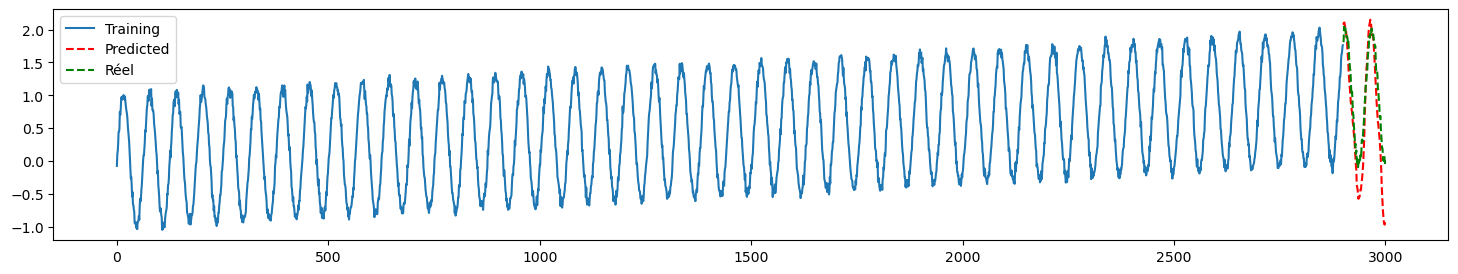

In [17]:
fig = plt.figure(figsize=(18,3))
plt.plot(range(x0[:DATA_SIZE-FORCAST].shape[0]),x0[:DATA_SIZE-FORCAST], label="Training");
plt.plot(range(x0[:DATA_SIZE-FORCAST].shape[0], x0.shape[0]),x0[DATA_SIZE-FORCAST:DATA_SIZE], 'r--', label="Predicted");
plt.plot(range(x1[:DATA_SIZE-FORCAST].shape[0], x1.shape[0]),x1[DATA_SIZE-FORCAST:DATA_SIZE], 'g--', label="Réel");
plt.legend();